Epoch 0 | Loss: 1.129 | Test Accuracy: 0.233
Epoch 20 | Loss: 0.609 | Test Accuracy: 0.767
Epoch 40 | Loss: 0.628 | Test Accuracy: 0.767
Epoch 60 | Loss: 0.626 | Test Accuracy: 0.767
Epoch 80 | Loss: 0.632 | Test Accuracy: 0.767
Epoch 100 | Loss: 0.601 | Test Accuracy: 0.767


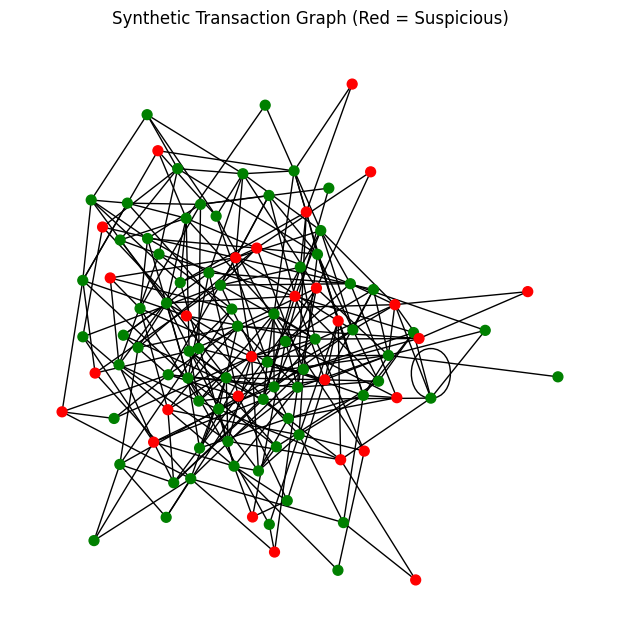


✅ Final Test Accuracy: 76.67 %


In [3]:
# ===============================
# Graph Transaction Network Analysis
# ===============================

# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# -------------------------------
# Step 1: Create Synthetic Transaction Graph
# -------------------------------
num_nodes = 100  # 100 accounts/wallets
num_edges = 300  # 300 transactions

# Random edges (transactions)
edges = np.random.randint(0, num_nodes, (2, num_edges))

# Node features: amount + frequency of transactions
x = torch.tensor(np.random.rand(num_nodes, 2), dtype=torch.float)

# Node labels: 0 = normal, 1 = suspicious
y = torch.tensor(np.random.choice([0,1], num_nodes, p=[0.8,0.2]), dtype=torch.long)

# Convert edges to PyTorch Geometric format
data = Data(x=x, edge_index=torch.tensor(edges, dtype=torch.long), y=y)

# -------------------------------
# Step 2: Define Graph Neural Network (GCN)
# -------------------------------
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# -------------------------------
# Step 3: Initialize Model, Optimizer, Loss
# -------------------------------
model = GCN(in_channels=2, hidden_channels=8, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# -------------------------------
# Step 4: Split Train/Test Nodes
# -------------------------------
train_mask, test_mask = train_test_split(range(num_nodes), test_size=0.3)

# -------------------------------
# Step 5: Training Loop
# -------------------------------
for epoch in range(101):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model.eval()
        pred = out.argmax(dim=1)
        acc = (pred[test_mask] == data.y[test_mask]).sum().item() / len(test_mask)
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | Test Accuracy: {acc:.3f}")

# -------------------------------
# Step 6: Visualize Transaction Graph
# -------------------------------
plt.figure(figsize=(6,6))
G = nx.Graph()
G.add_edges_from(edges.T)
color_map = ['red' if y[i]==1 else 'green' for i in range(num_nodes)]
nx.draw(G, node_color=color_map, with_labels=False, node_size=50)
plt.title("Synthetic Transaction Graph (Red = Suspicious)")
plt.show()

# -------------------------------
# Step 7: Display Final Accuracy
# -------------------------------
model.eval()
pred = model(data).argmax(dim=1)
final_acc = (pred[test_mask] == data.y[test_mask]).sum().item() / len(test_mask)
print("\n✅ Final Test Accuracy:", round(final_acc*100, 2), "%")